In [8]:
import numpy as np
import joblib
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from tensorflow.keras.layers import SimpleRNN, Dense, Dropout

In [2]:
X = np.load("../datasets/processed/X_lstm_08.npy")
y = np.load("../datasets/processed/y_lstm_08.npy")

In [3]:
X_flat = X.reshape(-1, 1)
y_flat = y.reshape(-1, 1)

In [4]:
x_scaler = MinMaxScaler()
y_scaler = MinMaxScaler()

In [5]:
X_scaled = x_scaler.fit_transform(X_flat).reshape(X.shape[0], X.shape[1])
y_scaled = y_scaler.fit_transform(y_flat)

In [6]:
X_scaled = X_scaled.reshape((X_scaled.shape[0], X_scaled.shape[1], 1))

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y_scaled, test_size=0.2, shuffle=False
)

In [9]:
rnn_model = Sequential()


rnn_model.add(SimpleRNN(units=64, return_sequences=True, input_shape=(X_train.shape[1], X_train.shape[2])))
rnn_model.add(Dropout(0.2))


rnn_model.add(SimpleRNN(units=64, return_sequences=True))
rnn_model.add(Dropout(0.2))

rnn_model.add(SimpleRNN(units=32))
rnn_model.add(Dropout(0.2))


rnn_model.add(Dense(1)) 

2025-05-20 23:38:08.809508: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M4 Pro
2025-05-20 23:38:08.809668: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 24.00 GB
2025-05-20 23:38:08.809680: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 8.00 GB
2025-05-20 23:38:08.809939: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2025-05-20 23:38:08.809952: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)
/Users/ruveenjayasinghe/Documents/GitHub/Traffic-Guidance-System/TBRGSvenv/lib/python3.9/site-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`inp

In [10]:
rnn_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn (SimpleRNN)          │ (None, 8, 64)          │         4,224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 8, 64)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_1 (SimpleRNN)        │ (None, 8, 64)          │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 8, 64)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_2 (SimpleRNN)        │ (None, 32)             │         3,104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 15,617 (61.00 KB)

 Trainable params: 15,617 (61.00 KB)

 Non-trainable params: 0 (0.00 B)

In [11]:
rnn_model.compile(optimizer='adam', loss='mse')

In [16]:
history = rnn_model.fit(
    X_train, y_train,
    epochs=3,
    batch_size=64,
    validation_data=(X_test, y_test),
   
)

Epoch 1/3
5027/5027 ━━━━━━━━━━━━━━━━━━━━ 532s 106ms/step - loss: 0.0025 - val_loss: 0.0014
Epoch 2/3
5027/5027 ━━━━━━━━━━━━━━━━━━━━ 535s 106ms/step - loss: 0.0024 - val_loss: 0.0015
Epoch 3/3
5027/5027 ━━━━━━━━━━━━━━━━━━━━ 535s 106ms/step - loss: 0.0024 - val_loss: 0.0016


In [18]:
rnn_model.save("../models/rnn_model_08step.h5")



4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 163ms/step


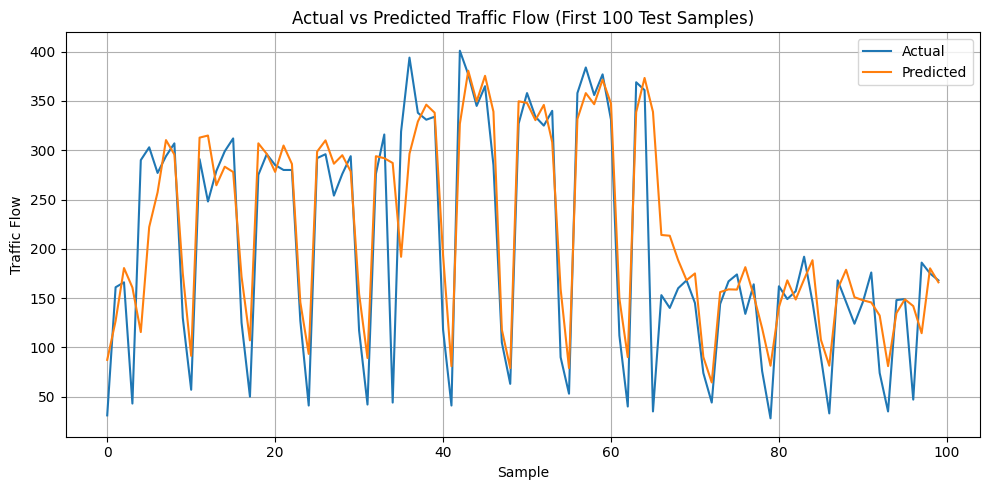

In [19]:
import matplotlib.pyplot as plt

y_pred_scaled = rnn_model.predict(X_test[:100])
y_pred = y_scaler.inverse_transform(y_pred_scaled)
y_true = y_scaler.inverse_transform(y_test[:100].reshape(-1, 1))


plt.figure(figsize=(10, 5))
plt.plot(y_true, label="Actual")
plt.plot(y_pred, label="Predicted")
plt.xlabel("Sample")
plt.ylabel("Traffic Flow")
plt.title("Actual vs Predicted Traffic Flow (First 100 Test Samples)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


In [20]:
from sklearn.metrics import mean_absolute_error, r2_score

mae = mean_absolute_error(y_true, y_pred)
r2 = r2_score(y_true, y_pred)

print(" MAE (Mean Absolute Error):", round(mae, 2))
print(" R² Score:", round(r2, 4))

 MAE (Mean Absolute Error): 37.0
 R² Score: 0.7356


In [23]:
from tensorflow.keras.models import load_model

lstm_model = load_model("../models/lstm_model_08step.h5", compile=False)
gru_model = load_model("../models/GRU.h5", compile=False)
rnn_model = load_model("../models/rnn_model_08step.h5", compile=False)


In [24]:

y_pred_lstm = lstm_model.predict(X_test[:100])
y_pred_gru = gru_model.predict(X_test[:100])
y_pred_rnn = rnn_model.predict(X_test[:100])


y_pred_lstm = y_scaler.inverse_transform(y_pred_lstm)
y_pred_gru = y_scaler.inverse_transform(y_pred_gru)
y_pred_rnn = y_scaler.inverse_transform(y_pred_rnn)
y_true = y_scaler.inverse_transform(y_test[:100].reshape(-1, 1))


4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step


1/4 ━━━━━━━━━━━━━━━━━━━━ 0s 118ms/stepWARNING:tensorflow:6 out of the last 12 calls to <function TensorFlowTrainer.make_predict_function.<locals>.one_step_on_data_distributed at 0x353783430> triggered tf.function retracing. Tracing is expensive and the excessive number of tracings could be due to (1) creating @tf.function repeatedly in a loop, (2) passing tensors with different shapes, (3) passing Python objects instead of tensors. For (1), please define your @tf.function outside of the loop. For (2), @tf.function has reduce_retracing=True option that can avoid unnecessary retracing. For (3), please refer to https://www.tensorflow.org/guide/function#controlling_retracing and https://www.tensorflow.org/api_docs/python/tf/function for  more details.


4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step
